In [ ]:
# WORLD CUP PSYCOLOGYCAL PRESSURE ANALYSIS - HOW TEAMS HAVE HISTORICALLY BEEN VULNERABLE AND/OR RESILIENT

# install dependencies as needed
import kagglehub
import pandas as pd
import re
import ast
import sklearn.preprocessing

# set the path to the file you'd like to load
# the 'file_path' must refer to a specific file within the dataset, not the dataset URL.
file_path = 'matches_1930_2022.csv'

# load the latest version
worldcup_matches_df = kagglehub.dataset_load(
  kagglehub.KaggleDatasetAdapter.PANDAS,
  'piterfm/fifa-football-world-cup',
  file_path,
)

# to improve table visualisation and avoid table breaks
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

100%|██████████| 691k/691k [00:00<00:00, 1.72MB/s]


In [ ]:
# FIRST INDEX
# CLUTCH COLLAPSE INDEX (CCI)
# when a team collapses under pressure: conceeding adjacent goals with less than 10min interval, conceeding goals in the last 10min, conceeding goals between 90-120min,
# losing an in-game penalty and not recovering after (not scoring for the lost opportunity)

# each collapse category will be weighted differently. the calculation logic will be:
# goals in the last 10min: +1 CCI point - for each goal
# goals during prorrogation (after interval) 90-120min: +2 CCI points - for each goal
# adjacent goal pairs under than 10min: +2 CCI points - for each adjacent pair
# ps: intervals should reset the time count between goals.

# the logic for CCI normalization will be:
# 1. calculate raw CCI per team
# 2. Divide by matches played → CCI rate (average performance)
# 3. apply min-max to the CCI rate → normalized CCI

In [ ]:
# SECOND INDEX
# PRESSURE CONVERSION RATE (PCR)
# when a team is able to convert an initially bad situation into a win: loses a penalty in game and compensates after,
# scores a penalty shootout when team was behind in the penalty dispute, starts conceded but ends up winning the match, is 2 or more goals behind and set for a draw at least

# all PCR category will be weighted differently. the calculation logic will be:
# each time a team was behind in the penalty shootout but ended up winning (dispute level): +2 PCR points
# each time a team conceded the first goal and wins (match level): +2 PCR points
# each time a team is 2 or more goals behind and scores to draw or lead (sequence level): (1 + goal delta) PCR points

# the logic for PCR normalization will be:
# 1. count PCR recoveries per team
# 2. divide by matches where team was losing at some point (not total matches - average performance)
# 3. apply Min-Max → normalized PCR

In [ ]:
# let's consider 1 event = 1 attempt to score (goal, own goal, penalty or miss penalty)
# events will be a list of dictionaries, each dictonary key will represent 1 column we need to have in our analysis dataset
events = []

# we will take the original dataset that was in wide format, and unfold it in our analysis dataset of long format
# in the original dataset, each row represents one match
# in our analysis dataset, each row represents one event

# we will fill up the events list in parts
# since the raw data is not structured, we can not use common vectorized pandas methods like explode() or melt()
# we'll use instead iterrows() to allow personalized python logic

# first, let's add the columns about the match context: match_id, year, round (the same logic for any event)
for index, row in worldcup_matches_df.iterrows():

  match_context = {
      "match_id": str(row["Year"])+"_"+row["home_team"][:3].upper()+"_"+row["away_team"][:3].upper(),
      "year": row["Year"],
      "round": row["Round"],
  }

  # second, let's add the data about the goals scored by the home team
  # we'll need to access the str in home_goal_long and split it by the characters | and ·
  if isinstance(row["home_goal"], str):
    all_home_goals = row["home_goal"].split("|")
    for i in all_home_goals:
      goal_data = i.split("·")
      goal_data_minute = goal_data[1].strip().split("+") #transform the minutes in int and remove all white spaces
      home_goal_data = {
          **match_context,
          "team_scoring": row["home_team"],
          "team_suffering": row["away_team"],
          "goal_minute": int(goal_data_minute[0]),
          "event_type": "goal"
      }
      events.append(home_goal_data)

  # the same for the away team
  if isinstance(row["away_goal"], str):
    all_away_goals = row["away_goal"].split("|")
    for i in all_away_goals:
      goal_data = i.split("·")
      goal_data_minute = goal_data[1].strip().split("+") #transform the minutes in int and remove all white spaces
      away_goal_data = {
          **match_context,
          "team_scoring": row["away_team"],
          "team_suffering": row["home_team"],
          "goal_minute": int(goal_data_minute[0]),
          "event_type": "goal"
      }
      events.append(away_goal_data)

  # third, let's add the data about own goals by home team
  if isinstance(row["home_own_goal"], str):
    all_home_own_goals = row["home_own_goal"].split("|")
    for i in all_home_own_goals:
      goal_data = i.split("·")
      goal_data_minute = goal_data[1].strip().split("+") #transform the minutes in int and remove all white spaces
      home_own_goal_data = {
          **match_context,
          "team_scoring": row["away_team"],
          "team_suffering": row["home_team"],
          "goal_minute": int(goal_data_minute[0])+int(goal_data_minute[1]) if len(goal_data_minute) > 1 else int(goal_data_minute[0]),
          "event_type": "own goal"
      }
      events.append(home_own_goal_data)

  # the same for away team
  if isinstance(row["away_own_goal"], str):
    all_away_own_goals = row["away_own_goal"].split("|")
    for i in all_away_own_goals:
      goal_data = i.split("·")
      goal_data_minute = goal_data[1].strip().split("+") #transform the minutes in int and remove all white spaces
      away_own_goal_data = {
          **match_context,
          "team_scoring": row["home_team"],
          "team_suffering": row["away_team"],
          "goal_minute": int(goal_data_minute[0])+int(goal_data_minute[1]) if len(goal_data_minute) > 1 else int(goal_data_minute[0]),
          "event_type": "own goal"
      }
      events.append(away_own_goal_data)

  # forth, let's add the data about penalty goals by home team
  if isinstance(row["home_penalty_goal"], str):
    all_home_penalty_goals = row["home_penalty_goal"].split("|")
    for i in all_home_penalty_goals:
      goal_data = i.split("·")
      goal_data_minute = goal_data[1].strip().split("+") #transform the minutes in int and remove all white spaces
      home_penalty_goal_data = {
          **match_context,
          "team_scoring": row["home_team"],
          "team_suffering": row["away_team"],
          "goal_minute": int(goal_data_minute[0]),
          "event_type": "penalty goal"
      }
      events.append(home_penalty_goal_data)

  # now, the same for away team
  if isinstance(row["away_penalty_goal"], str):
    all_away_penalty_goals = row["away_penalty_goal"].split("|")
    for i in all_away_penalty_goals:
      goal_data = i.split("·")
      goal_data_minute = goal_data[1].strip().split("+") #transform the minutes in int and remove all white spaces
      home_away_goal_data = {
          **match_context,
          "team_scoring": row["away_team"],
          "team_suffering": row["home_team"],
          "goal_minute": int(goal_data_minute[0]),
          "event_type": "penalty goal"
      }
      events.append(home_away_goal_data)

  if isinstance(row["home_penalty_miss_long"], str):
    try:
        all_home_penalty_miss = ast.literal_eval(row["home_penalty_miss_long"])
    except (ValueError, SyntaxError):
        cleaned = row["home_penalty_miss_long"].strip("[]").split("', '")
        all_home_penalty_miss = [i.strip("'") for i in cleaned]

    for i in all_home_penalty_miss:
        minute_match = re.search(r"(\d+)[+&]", i)
        home_penalty_miss_data = {
            **match_context,
            "team_scoring": row["home_team"],
            "team_suffering": row["away_team"],
            "goal_minute": int(minute_match.group(1)) if minute_match else None,
            "event_type": "missed penalty goal"
        }
        events.append(home_penalty_miss_data)

  # now, the same for away team
  if isinstance(row["away_penalty_miss_long"], str):
    try:
        all_away_penalty_miss = ast.literal_eval(row["away_penalty_miss_long"])
    except (ValueError, SyntaxError):
        cleaned = row["away_penalty_miss_long"].strip("[]").split("', '")
        all_away_penalty_miss = [i.strip("'") for i in cleaned]

    for i in all_away_penalty_miss:
        minute_match = re.search(r"(\d+)[+&]", i)
        away_penalty_miss_data = {
            **match_context,
            "team_scoring": row["away_team"],
            "team_suffering": row["home_team"],
            "goal_minute": int(minute_match.group(1)) if minute_match else None,
            "event_type": "missed penalty goal"
        }
        events.append(away_penalty_miss_data)

  # sixth, let's add the data about penalty shootout goals by home team
  # the structure here is different because we only have the long str format available
  if isinstance(row["home_penalty_shootout_goal_long"], str):
    all_home_shout_penalty_goals = row["home_penalty_shootout_goal_long"].split(",")
    for i in all_home_shout_penalty_goals:
      penalty_score = i.split("|")
      penalty_score = penalty_score[1].strip().split(":")
      home_penalty_goal_data = {
          **match_context,
          "team_scoring": row["home_team"],
          "team_suffering": row["away_team"],
          "score_after": penalty_score,
          "was_behind": "yes" if int(penalty_score[0])-1 < int(penalty_score[-1]) else "no",
          "event_type": "penalty shootout goal"
      }
      events.append(home_penalty_goal_data)

  # now, the same for away team
  if isinstance(row["away_penalty_shootout_goal_long"], str):
    all_away_shout_penalty_goals = row["away_penalty_shootout_goal_long"].split(",")
    for i in all_away_shout_penalty_goals:
      penalty_score = i.split("|")
      penalty_score = penalty_score[1].strip().split(":")
      away_penalty_goal_data = {
          **match_context,
          "team_scoring": row["away_team"],
          "team_suffering": row["home_team"],
          "score_after": penalty_score[::-1],
          "was_behind": "yes" if int(penalty_score[-1])-1 < int(penalty_score[0]) else "no",
          "event_type": "penalty shootout goal"
      }
      events.append(away_penalty_goal_data)


  # seventh, let's add the data about penalty shootout miss goals by home team
  if isinstance(row["home_penalty_shootout_miss_long"], str):
    all_home_shout_penalty_miss_goals = row["home_penalty_shootout_miss_long"].split(",")
    for i in all_home_shout_penalty_miss_goals:
      penalty_score = i.split("|")
      penalty_score = penalty_score[1].strip().split(":")
      home_penalty_miss_data = {
          **match_context,
          "team_scoring": row["home_team"],
          "team_suffering": row["away_team"],
          "score_after": penalty_score,
          "was_behind": "yes" if int(penalty_score[0]) < int(penalty_score[-1]) else "no",
          "event_type": "missed penalty shootout goal"
      }
      events.append(home_penalty_miss_data)

  # now, the same for away team
  if isinstance(row["away_penalty_shootout_miss_long"], str):
    all_away_shout_penalty_miss_goals = row["away_penalty_shootout_miss_long"].split(",")
    for i in all_away_shout_penalty_miss_goals:
      penalty_score = i.split("|")
      penalty_score = penalty_score[1].strip().split(":")
      away_penalty_miss_data = {
          **match_context,
          "team_scoring": row["away_team"],
          "team_suffering": row["home_team"],
          "score_after": penalty_score[::-1],
          "was_behind": "yes" if int(penalty_score[-1]) < int(penalty_score[0]) else "no",
          "event_type": "missed penalty shootout goal"
      }
      events.append(away_penalty_miss_data)

analysis_df = pd.DataFrame(events)

# sort by match and minute first
analysis_df = analysis_df.sort_values(['match_id', 'goal_minute']).reset_index(drop=True)

# filter only goal events (not shootout)
goal_events = analysis_df[analysis_df['event_type'].isin(['goal', 'own goal', 'penalty goal', 'missed penalty goal'])]

# for each goal row, count cumulative goals per team per match up to that minute
def get_score_after(row):
    same_match = goal_events[
        (goal_events['match_id'] == row['match_id']) &
        (goal_events['goal_minute'] <= row['goal_minute']) &
        (goal_events['event_type'] != 'missed penalty goal')
    ]
    team_scoring = len(same_match[same_match['team_scoring'] == row['team_scoring']])
    team_suffering = len(same_match[same_match['team_scoring'] == row['team_suffering']])
    score = [team_scoring, team_suffering]
    was_behind = 'yes' if team_scoring - 1 < team_suffering else 'no'
    return pd.Series({'score_after': score, 'was_behind': was_behind})

analysis_df.loc[
    analysis_df['event_type'].isin(['goal', 'own goal', 'penalty goal']),
    ['score_after','was_behind']] = analysis_df[ analysis_df['event_type'].isin(['goal', 'own goal', 'penalty goal'])].apply(get_score_after, axis=1)

In [ ]:
# @title
# checking if own goals data represents pressure, when do they happen?
# print(analysis_df[analysis_df['event_type']=='own goal']['goal_minute'].mean())
# analysis_df[analysis_df['event_type']=='own goal']['goal_minute'].hist(bins=45)
# plt.xlabel('goal minute')
# plt.ylabel('frequency')
# plt.show()

# own goals show no significant concentration in high pressure moments, therefore they add noise without signal to the analysis
# detail: our histogram has an apparently flat line, but for a small N this can be just noise looking like uniformity

In [ ]:
# winner of each match, will be needed for further analysis
def get_winner(row):
    if row['home_score'] > row['away_score']:
        return row['home_team']
    elif row['away_score'] > row['home_score']:
        return row['away_team']
    elif row['home_penalty'] > row['away_penalty']:
        return row['home_team']
    elif row['away_penalty'] > row['home_penalty']:
        return row['away_team']
    else:
        return 'draw'

match_winners = pd.DataFrame()
match_winners['match_id'] = (worldcup_matches_df['Year'].astype(str) + '_' + worldcup_matches_df['home_team'].str[:3].str.upper() + '_' + worldcup_matches_df['away_team'].str[:3].str.upper())
match_winners['winner'] = worldcup_matches_df.apply(get_winner, axis=1)

In [ ]:
#FUNCTION TO CALCULATE BOTH INDEX FOR DIFFERENT FILTER CONDITIONS

def run_analysis(year_min, year_max, rounds=None, min_matches_played=None):

    # ── shared filters ────────────────────────────────────────
    filtered_df = analysis_df.copy()
    filtered_df = filtered_df[filtered_df['year'].between(year_min, year_max)]
    if rounds:
        filtered_df = filtered_df[filtered_df['round'].isin(rounds)]

    # matches_per_team filtered by year & rounds
    filtered_matches = worldcup_matches_df[worldcup_matches_df['Year'].between(year_min, year_max)]
    if rounds:
        filtered_matches = filtered_matches[filtered_matches['Round'].isin(rounds)]
    home_counts = filtered_matches['home_team'].value_counts()
    away_counts = filtered_matches['away_team'].value_counts()
    matchs_per_team = home_counts.add(away_counts, fill_value=0).astype(int).reset_index()
    matchs_per_team.columns = ['team', 'matches_played']

    # ── CCI ───────────────────────────────────────────────────
    cci_events = filtered_df[filtered_df['event_type'].isin(['goal'])]
    cci_events = cci_events.drop(columns=['score_after', 'was_behind'])
    cci_events['period'] = cci_events['goal_minute'].apply(
        lambda x: 'extra_time' if x > 90 else 'regular'
    )

    # category 1 - last 10 min goal
    def score_last_10min(group):
      return len(group[group['goal_minute'].between(80, 90)])

    # category 2 - prorrogation goal
    def score_90_120min(group):
        return len(group[group['goal_minute'].between(90, 120)]) * 2

    # category 3 - adjacent goals
    def score_adjacent_goals(group):
        goals = group.sort_values('goal_minute')
        goals['gap'] = goals['goal_minute'].diff()

        # reset count at halftime
        goals['gap'] = goals.apply(
            lambda x: None
            if x['goal_minute'] > 45 and (x['goal_minute'] - x['gap']) < 45
            else x['gap'], axis=1)

        # reset count at extra time
        goals['gap'] = goals.apply(
            lambda x: None
            if x['goal_minute'] > 90 and (x['goal_minute'] - x['gap']) < 90
            else x['gap'], axis=1)

        adjacent_paris = goals[goals['gap'] < 10]
        return len(adjacent_paris) * 2

    # calculating final CCI
    def calculate_cci(group):
        cci_last_10min = score_last_10min(group)
        cci_90_120min = score_90_120min(group)
        cci_adjacent_goals = score_adjacent_goals(group)
        team_name = group.name
        return (cci_last_10min + cci_90_120min + cci_adjacent_goals)

    cci_results_abs = cci_events.groupby('team_suffering').apply(calculate_cci, include_groups=False).reset_index()

    # check what columns actually exist after reset_index???
    cci_results_abs = cci_results_abs.rename(columns={'team_suffering': 'team', 0: 'CCI'})
    cci_results = pd.merge(cci_results_abs, matchs_per_team, on='team', how='left')
    cci_results = cci_results[cci_results['matches_played'] >= min_matches_played]
    cci_results['CCI avg'] = (cci_results['CCI'] / cci_results['matches_played']).round(3)

    # ── PCR ───────────────────────────────────────────────────

    # category 1 - was behind in penalty dispute and ended up winning penalty dispute
    shootout_behind = filtered_df[
        (filtered_df['event_type'].isin(['penalty shootout goal', 'missed penalty shootout goal'])) &
        (filtered_df['was_behind'] == 'yes')
    ].merge(match_winners, on='match_id', how='left')
    shootout_behind = shootout_behind.drop_duplicates(subset=['match_id', 'team_scoring'])
    cat1_opportunities = shootout_behind.groupby('team_scoring').size().reset_index()
    cat1_opportunities.columns = ['team', 'opportunities']
    cat1_recoveries = shootout_behind[shootout_behind['team_scoring'] == shootout_behind['winner']].groupby('team_scoring').size().reset_index()
    cat1_recoveries.columns = ['team', 'recoveries']
    pcr_cat1 = cat1_opportunities.merge(cat1_recoveries, on='team', how='left').fillna(0)
    pcr_cat1['pcr_cat1'] = (pcr_cat1['recoveries'] / pcr_cat1['opportunities']).round(3)

    # category 2 - conceded first goal in match and ended up winning match
    first_goals = filtered_df[
        filtered_df['event_type'].isin(['goal', 'own goal', 'penalty goal'])
    ].sort_values(['match_id', 'goal_minute']).groupby('match_id').first().reset_index()
    first_goals = first_goals[['match_id', 'team_suffering']].rename(columns={'team_suffering': 'team'})
    first_goals = first_goals.merge(match_winners, on='match_id', how='left')
    cat2_opportunities = first_goals.groupby('team').size().reset_index()
    cat2_opportunities.columns = ['team', 'opportunities']
    cat2_recoveries = first_goals[first_goals['team'] == first_goals['winner']].groupby('team').size().reset_index()
    cat2_recoveries.columns = ['team', 'recoveries']
    pcr_cat2 = cat2_opportunities.merge(cat2_recoveries, on='team', how='left').fillna(0)
    pcr_cat2['pcr_cat2'] = (pcr_cat2['recoveries'] / pcr_cat2['opportunities']).round(3)

    # category 3 - was 2+ goals behind in match score and ended up setting a draw or winning match
    goal_events = filtered_df[
        filtered_df['event_type'].isin(['goal', 'own goal', 'penalty goal']) &
        filtered_df['score_after'].notna()
    ].copy()
    goal_events['score_before_team'] = goal_events['score_after'].apply(lambda x: x[0] - 1)
    goal_events['score_before_opponent'] = goal_events['score_after'].apply(lambda x: x[1])
    goal_events['deficit_before'] = goal_events['score_before_opponent'] - goal_events['score_before_team']
    cat3_events = goal_events[goal_events['deficit_before'] >= 2].copy()
    cat3_events = cat3_events.merge(match_winners, on='match_id', how='left')
    cat3_events['drew_or_led'] = (
        (cat3_events['team_scoring'] == cat3_events['winner']) |
        (cat3_events['winner'] == 'draw')
    )
    cat3_events = cat3_events.groupby(['match_id', 'team_scoring']).agg(
        drew_or_led=('drew_or_led', 'max')
    ).reset_index()
    cat3_opportunities = cat3_events.groupby('team_scoring').size().reset_index()
    cat3_opportunities.columns = ['team', 'opportunities']
    cat3_recoveries = cat3_events[cat3_events['drew_or_led'] == True].groupby('team_scoring').size().reset_index()
    cat3_recoveries.columns = ['team', 'recoveries']
    pcr_cat3 = cat3_opportunities.merge(cat3_recoveries, on='team', how='left').fillna(0)
    pcr_cat3['pcr_cat3'] = (pcr_cat3['recoveries'] / pcr_cat3['opportunities']).round(3)

    # merging all 3 categories in the same dataframe
    pcr_results = pcr_cat1.merge(pcr_cat2, on='team', how='outer').merge(pcr_cat3, on='team', how='outer')
    pcr_results = pcr_results.drop(columns=['opportunities', 'recoveries', 'opportunities_x', 'recoveries_x', 'opportunities_y', 'recoveries_y'])
    pcr_results['categories_count'] = pcr_results[['pcr_cat1', 'pcr_cat2', 'pcr_cat3']].notna().sum(axis=1)
    pcr_results = pcr_results.fillna(0)
    pcr_results['PCR avg'] = (
        (pcr_results['pcr_cat1'] + pcr_results['pcr_cat2'] + pcr_results['pcr_cat3']) /
        pcr_results['categories_count']
    ).round(3)

    print(cci_results[cci_results['team']=='Portugal'])

    return cci_results, pcr_results

In [ ]:
# define what will be plotted
all_rounds = ['Final', 'Final stage', 'Semi-finals', 'Quarter-finals', 'Round of 16', 'Group stage', 'Second group stage', 'First group stage', 'Second round', 'First round', 'Third-place match', 'Group stage play off']
eliminatory_rounds = ['Final', 'Final stage', 'Semi-finals', 'Quarter-finals', 'Round of 16']
non_eliminatory = ['Group stage', 'Second group stage', 'First group stage', 'Second round', 'First round', 'Third-place match', 'Group stage play off']
min_matches = 9

cci_eli, pcr_eli = run_analysis(1930, 2022, rounds=eliminatory_rounds, min_matches_played=min_matches)
cci_non, pcr_non = run_analysis(1930, 2022, rounds=non_eliminatory, min_matches_played=min_matches)

# since we're plotting for different rounds, add round type labels
cci_eli['round_type'] = 'eliminatory'
cci_non['round_type'] = 'non eliminatory'
pcr_eli['round_type'] = 'eliminatory'
pcr_non['round_type'] = 'non eliminatory'

# combine both into one dataframe each
cci_combined = pd.concat([cci_eli, cci_non], ignore_index=True)
pcr_combined = pd.concat([pcr_eli, pcr_non], ignore_index=True)

# normalize ONCE on the combined data to guarantee different round types are comparable
scaler_cci = sklearn.preprocessing.MinMaxScaler(feature_range=(0, 100))
cci_combined['CCI norm'] = scaler_cci.fit_transform(cci_combined[['CCI avg']]).round()

# invert CCI so higher = less vulnerable (more composed)
cci_combined['CCI norm'] = (100 - cci_combined['CCI norm'])

scaler_pcr = sklearn.preprocessing.MinMaxScaler(feature_range=(0, 100))
pcr_combined['PCR norm'] = scaler_pcr.fit_transform(pcr_combined[['PCR avg']]).round()

# split back by round type for plotting
scatter_eli = cci_combined[cci_combined['round_type'] == 'eliminatory'][['team', 'CCI norm', 'matches_played']].merge(
    pcr_combined[pcr_combined['round_type'] == 'eliminatory'][['team', 'PCR norm']], on='team', how='inner'
)
scatter_non = cci_combined[cci_combined['round_type'] == 'non eliminatory'][['team', 'CCI norm', 'matches_played']].merge(
    pcr_combined[pcr_combined['round_type'] == 'non eliminatory'][['team', 'PCR norm']], on='team', how='inner'
)

teams_to_plot = [
    # world cup winners
    "Brazil",
    "Germany",
    "France",
    "Argentina",
    "Spain",
    "England",
    "Uruguay",
    # strong european teams without a title
    "Netherlands",
    "Croatia",
    "Belgium",
    "Portugal",
    # other interesting teams for comparison
    "Mexico",
    "Switzerland",
    "Sweden",
    "United States",
    "Japan"
]

        team  CCI  matches_played  CCI avg
38  Portugal   11               9    1.222
        team  CCI  matches_played  CCI avg
55  Portugal   51              26    1.962


In [ ]:
# @title
%%capture
!pip install adjustText

In [ ]:
# @title
%%capture
!apt-get install -y fonts-lato

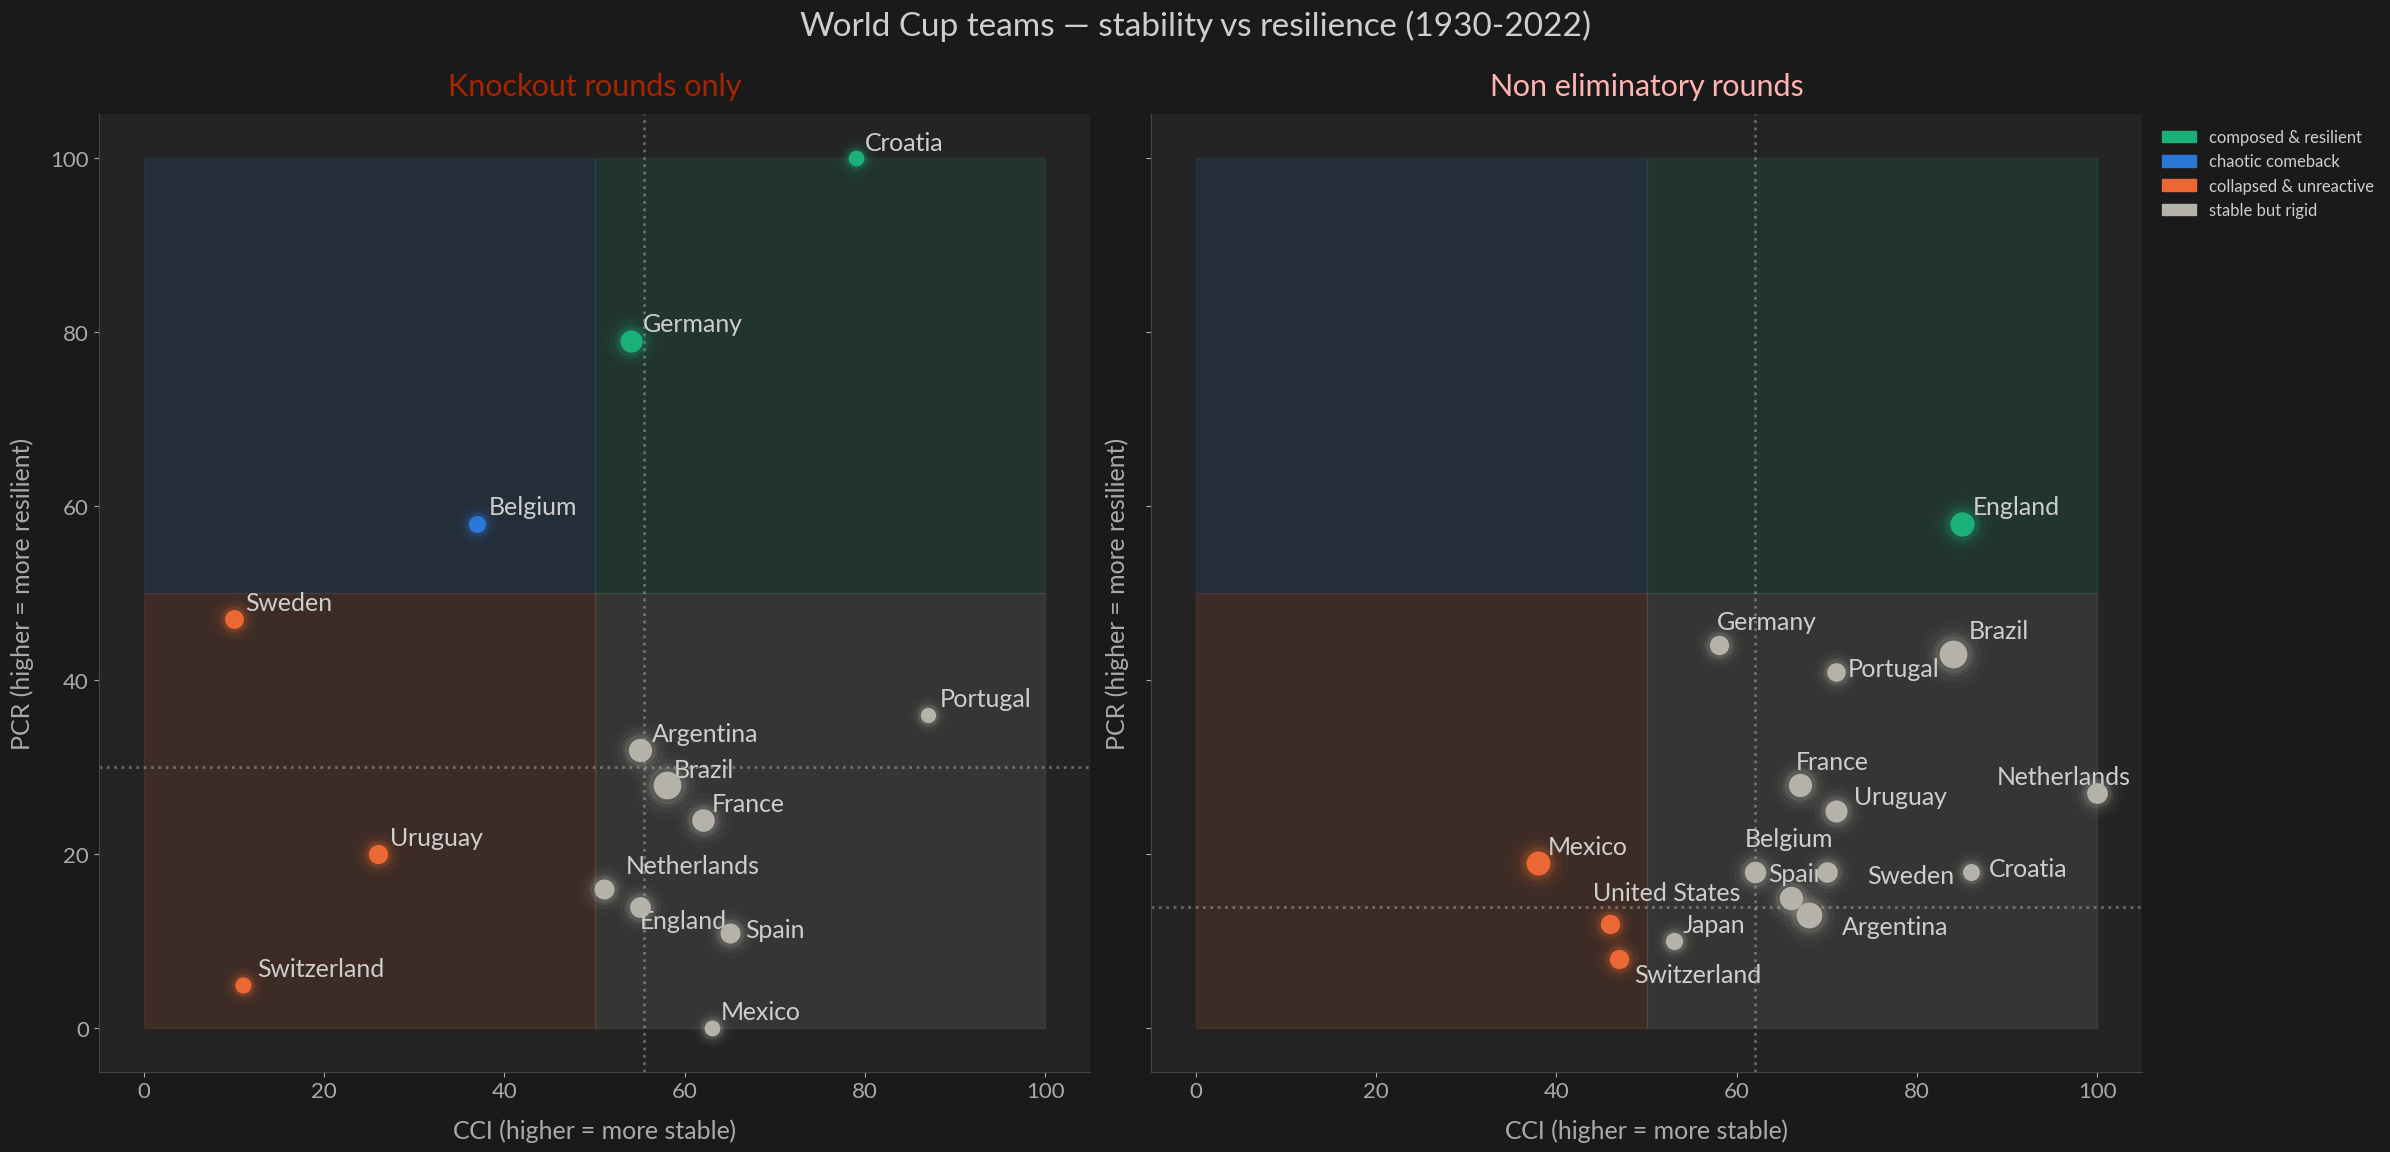

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from adjustText import adjust_text
from matplotlib.colors import to_rgba
import matplotlib as mpl
import matplotlib.font_manager as fm
import numpy as np
fm.fontManager.addfont('/usr/share/fonts/truetype/lato/Lato-Regular.ttf')
mpl.rcParams['font.family'] = 'Lato'

def get_quadrant(row):
    if row['CCI norm'] > 50 and row['PCR norm'] > 50:
        return 'composed & resilient'
    elif row['CCI norm'] <= 50 and row['PCR norm'] > 50:
        return 'chaotic comeback'
    elif row['CCI norm'] > 50 and row['PCR norm'] <= 50:
        return 'stable but rigid'
    else:
        return 'collapsed & unreactive'

palette = {
    'composed & resilient':   '#1baf7a',
    'chaotic comeback':       '#2a78d6',
    'collapsed & unreactive': '#eb6834',
    'stable but rigid':       '#b4b2a9',
}

# dark background colors
BG_DARK = '#1a1a1a'
BG_PANEL = '#242424'
TEXT_COLOR = '#cecece'
GRID_COLOR = '#333333'
SPINE_COLOR = '#444444'

def plot_scatter(ax, scatter_df, title, title_color):

    # calculate median beforing filtering teams_to_plot (median of all teams)
    cci_median = scatter_df['CCI norm'].median()
    pcr_median = scatter_df['PCR norm'].median()

    scatter_df = scatter_df[scatter_df['team'].isin(teams_to_plot)].copy()
    scatter_df['quadrant'] = scatter_df.apply(get_quadrant, axis=1)

    ax.set_facecolor(BG_PANEL)
    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)

    ax.fill_between(x=[0, 50],   y1=50, y2=100, alpha=0.12, color='#2a78d6')
    ax.fill_between(x=[50, 100], y1=50, y2=100, alpha=0.12, color='#1baf7a')
    ax.fill_between(x=[0, 50],   y1=0,  y2=50,  alpha=0.12, color='#eb6834')
    ax.fill_between(x=[50, 100], y1=0,  y2=50,  alpha=0.12, color='#b4b2a9')

    ax.axvline(x=cci_median, color='#ffffff', linestyle=':', linewidth=2, alpha=0.3)
    ax.axhline(y=pcr_median, color='#ffffff', linestyle=':', linewidth=2, alpha=0.3)

    texts = []
    for _, row in scatter_df.iterrows():
        color = palette[row['quadrant']]

        # scale dot size proportionally to matches played
        # min size 80, max size 400
        dot_size = 50 + (row['matches_played'] / scatter_df['matches_played'].max()) * 350

        for size, alpha in [(dot_size*6, 0.03), (dot_size*4, 0.06),
                            (dot_size*2.5, 0.10), (dot_size*1.8, 0.15)]:
            ax.scatter(row['CCI norm'], row['PCR norm'],
                      s=size, color=color, alpha=alpha, zorder=2, linewidths=0)

        ax.scatter(row['CCI norm'], row['PCR norm'],
                  s=dot_size, color=color, alpha=1.0, zorder=5, linewidths=0)

        # add team name to each dot
        texts.append(ax.text(
            row['CCI norm'], row['PCR norm'],
            row['team'], fontsize=18, color=TEXT_COLOR,
            ha='left', fontweight='normal'
        ))

    adjust_text(
        texts,
        x=scatter_df['CCI norm'].values,
        y=scatter_df['PCR norm'].values,
        ax=ax,
        expand_points=(3.0, 3.0),
        force_points=(5.0, 5.0),
        force_text=(1.0, 1.0),
        only_move={'points': 'xy', 'texts': 'xy'},
        avoid_points=True
    )

    ax.grid(False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color(SPINE_COLOR)
    ax.set_xlabel('CCI (higher = more stable)',
                  fontsize=18, color='#aaaaaa', labelpad=12)
    ax.set_ylabel('PCR (higher = more resilient)',
                  fontsize=18, color='#aaaaaa', labelpad=12)
    ax.tick_params(colors='#aaaaaa', labelsize=16)

    # colored subtitle (per graph)
    ax.set_title(title, fontsize=22, color=title_color, pad=14, fontweight='500')

# draw both plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 11), sharey=True, sharex=True)
fig.patch.set_facecolor(BG_DARK)

plot_scatter(ax1, scatter_eli, 'Knockout rounds only', title_color='#a62600')
plot_scatter(ax2, scatter_non, 'Non eliminatory rounds', title_color='#ffb4b2')

# shared legend
legend_elements = [
    mpatches.Patch(color=palette[l], label=l)
    for l in palette.keys()
]
legend = ax2.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.005, 1),
    fontsize=12,
    frameon=False,
    title_fontsize=15,
    labelcolor=TEXT_COLOR,
)

# set legend title color separately
legend.get_title().set_color(TEXT_COLOR)

# main title
fig.text(0.5, 1.02,
         'World Cup teams — stability vs resilience (1930-2022)',
         ha='center', fontsize=24, color=TEXT_COLOR, fontweight='500')

plt.tight_layout()
plt.savefig('cci_pcr_scatter_dark.png', dpi=150, bbox_inches='tight',
            facecolor=BG_DARK)
plt.show()
